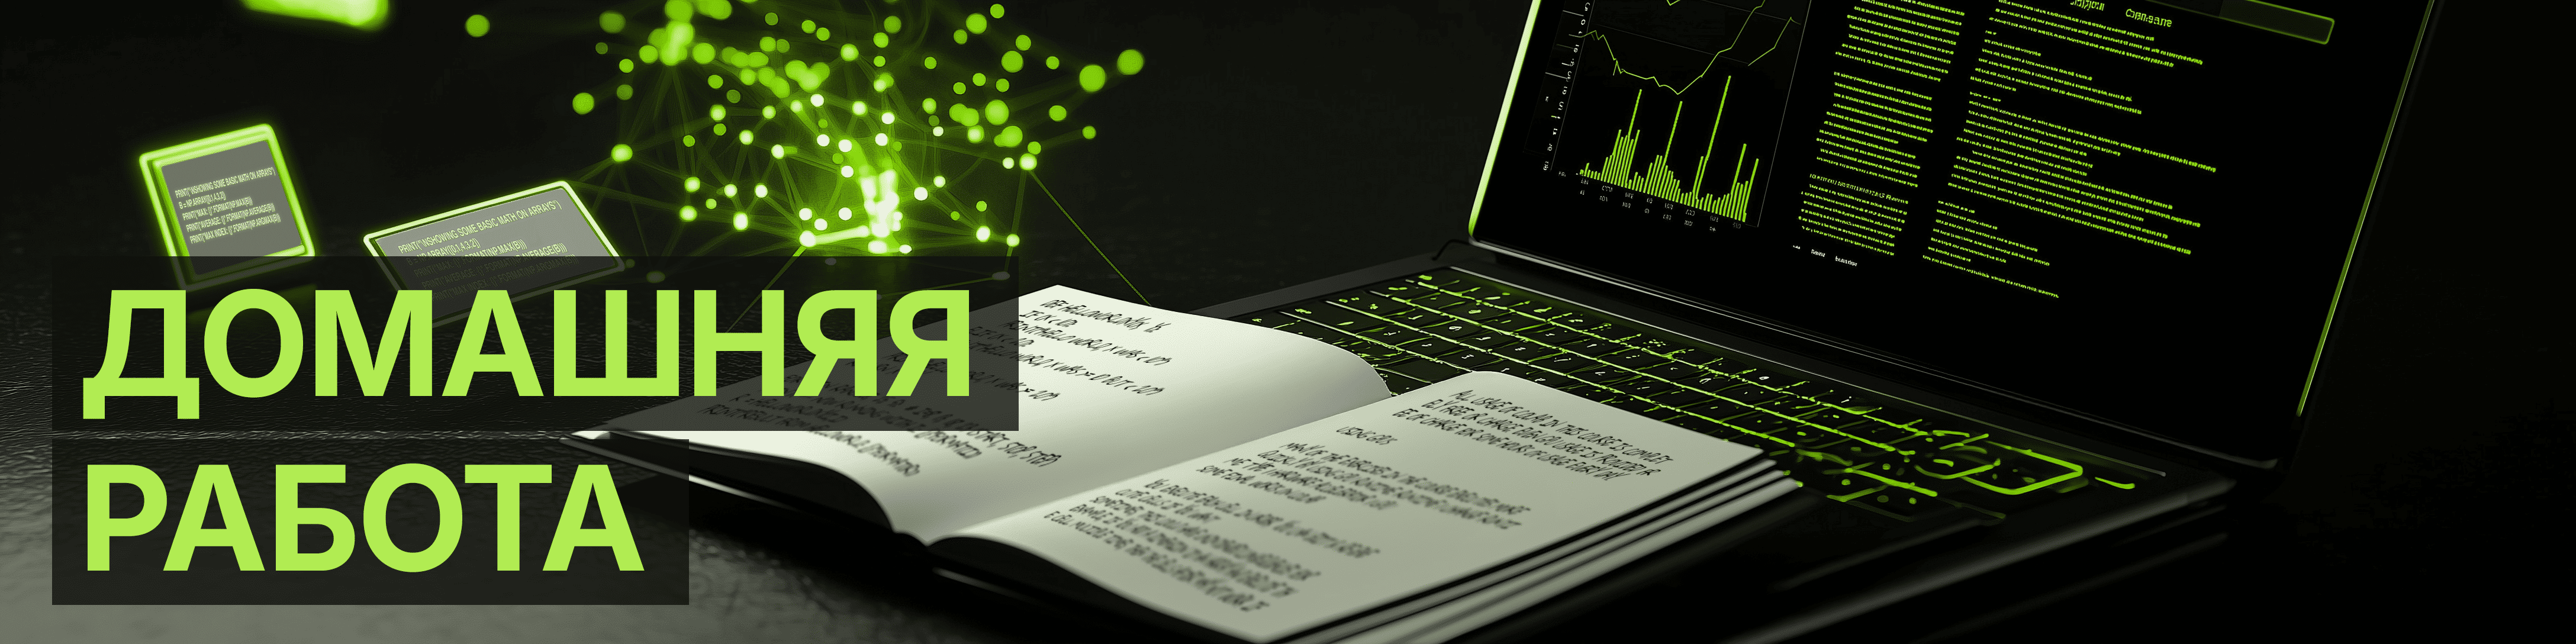

**Навигация по уроку**
1. [Рекурентные автокодировщики](https://colab.research.google.com/drive/1IkEXo9UWYWfHI5Yr62lvDEMboobHgdCG)
2. [Англо-русский переводчик](https://colab.research.google.com/drive/1M9mAMcAANpVaZdiNkNXDb4_WHnC5bFwu)
3. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Ваша задача, используя знания текущего урока обучить модель переводить предложения с английского языка на португальский.

2. В качестве словаря для англо-португальского перевода используйте набор данных из параллельных пар предложений на разных языках http://www.manythings.org/anki/ разделенных табуляцией.

3. Расщепите данные на обучающую выборку и выборку для тестирования модели.

4. Продемонстрируйте работу модели на 10 примерах из тестовой выборки. Сформируйте таблицу из трех колонок: английская фраза из тестовой выборки, португальский перевод из тестовой выборки, предсказанный перевод на португальский язык.

**Задание 2. На 4 балла:**

1. Вам необходимо выполнить задание на 3 балла, изменив механизм токенизации.

2. Для этого необходимо самостоятельно познакомиться с BPE-токенизацией (Byte Pair Encoding) и применить ее. Можно использовать как токенизацию по тексту, так и byte-level BPE-токенизацию по байтовым представлениям (именно так происходит токенизация у GPT моделей от OpenAI).

**ВАЖНО**. Даже если вы не планируете делать задание на 4 балла, хотя бы бегло изучите, как работает byte-level BPE-токенизация, именно она позволяет сжимать словарь до всего-лишь ~50k токенов, при том, что с его помощью всё ещё можно выразить любое слово на любом языке мира и даже эмодзи! Тем более Keras уже содержит готовые токенизаторы и довольно неплохое их описание.

**Задание 3. На 5 балла:**

Это творческое задание нацелено на проработку очень важного навыка любого программиста: умение реализовать проект по фрагментам кода от предыдущей команды.

Представьте, что вы пришли в новую компанию и вам дали следующий код, с помощью которого предыдущая команда, генерировала описания к изображениям:

In [ ]:
import numpy as np
import pandas as pd
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding, Concatenate
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_v3 import preprocess_input
from keras.preprocessing import image
from keras.models import Model

# загрузка предобученной модели InceptionV3
base_model = InceptionV3(weights='imagenet')
model = Model(base_model.input, base_model.layers[-2].output)

def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features

# чтение данных
captions_data_path = 'captions.txt'
images_path = 'images/'

captions = open(captions_data_path, 'r').read().strip().split('\n')
image_ids = []
captions_list = []
for line in captions:
    img_id, caption = line.split('\t')
    image_ids.append(img_id)
    captions_list.append(caption)

# токенизация
caption_tokenizer = Tokenizer()
caption_tokenizer.fit_on_texts(captions_list)
caption_sequences = caption_tokenizer.texts_to_sequences(captions_list)
caption_word_index = caption_tokenizer.word_index

# паддинг последовательностей
max_len_caption = max([len(txt) for txt in caption_sequences])

decoder_input_data = pad_sequences(caption_sequences, maxlen=max_len_caption, padding='post')

# смещение на один токен вправо для decoder_target_data
decoder_target_data = np.zeros((len(captions_list), max_len_caption, len(caption_word_index) + 1), dtype='float32')
for i, seqs in enumerate(caption_sequences):
    for t, token in enumerate(seqs):
        if t > 0:
            decoder_target_data[i, t - 1, token] = 1.0

# экстракция признаков изображений
image_features = np.zeros((len(image_ids), 2048))
for i, img_id in enumerate(image_ids):
    img_path = images_path + img_id
    image_features[i] = extract_features(img_path, model)

# гиперпараметры
latent_dim = 256
num_decoder_tokens = len(caption_word_index) + 1

# вход для признаков изображения
image_input = Input(shape=(2048,))

# вход для декодера
decoder_inputs = Input(shape=(None,))
decoder_embedding = Embedding(input_dim=num_decoder_tokens, output_dim=latent_dim)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=[image_input, image_input])
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# модель Seq2Seq
model = Model([image_input, decoder_inputs], decoder_outputs)
model.compile(optimizer='rmsprop', loss='categorical_crossentropy')
model.fit([image_features, decoder_input_data], decoder_target_data, batch_size=64, epochs=30, validation_split=0.2)

Ваша задача, как тимлида проекта, самостоятельно, не прибегая к помощи куратора:
1. Разобраться в работе кода.
2. Найти датасет с изображениями и подписи к ним.
3. Обучить модель по картинкам делать описание.
4. Продемонстрировать работу модели.

100%|██████████| 1.04G/1.04G [00:08<00:00, 139MB/s] 

Extracting files...


Датасет: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1
Images: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images
Captions: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/captions.txt
Images exists: True
Captions exists: True
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  

Количество подписей: 40455
Количество изображений: 8091
Колонки: ['image', 'caption']

Пропуски:
image      0
caption    0
dtype: int64

Пример:
image                              1000268201_693b

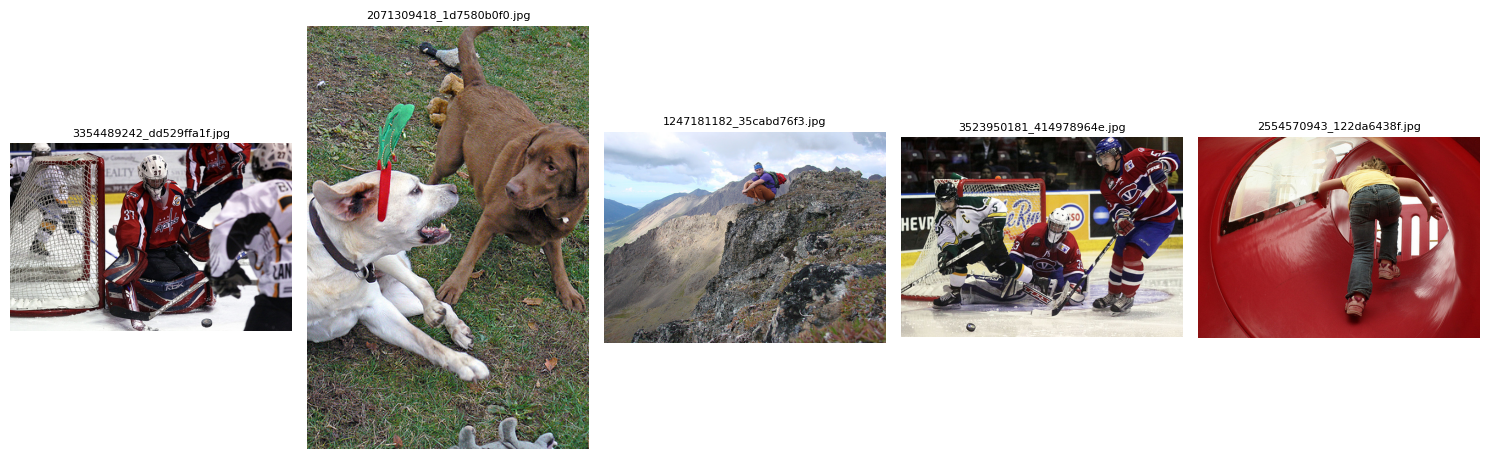

3354489242_dd529ffa1f.jpg

1. A goalie tries to block the puck in a hockey game .
2. A hockey goalie stops the puck .
3. People playing hockey .
4. Several hockey players move toward the puck next to a goal .
5. Two hockey teams compete .

2071309418_1d7580b0f0.jpg

1. A white dog wearing a christmas reindeer headband plays with a brown dog in the grass among some stuffed animals .
2. A white dog wearing reindeer ears is next to a brown dog .
3. A white dog with fake antlers on its head and a brown dog play together outdoors .
4. The white dog next to the brown dog is wearing a christmas headband .
5. Two dogs , one wearing christmas antlers , tussle on the grass .

1247181182_35cabd76f3.jpg

1. a man sits on a rock .
2. A man sitting on a cliff in the mountains .
3. A man wearing a blue shirt crouches on a rocky cliff .
4. A person posing on a mountaintop .
5. The man is sitting at the top of a rocky mountain .

3523950181_414978964e.jpg

1. A goalie is covering his net while two othe

In [1]:
# 1. Установка KaggleHub

%pip install -q kagglehub

# 2. Импорты

from pathlib import Path
import random

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image

# 3. Настройки

SEED = 42

random.seed(SEED)

TRAIN_IMAGES = 5000
VAL_IMAGES = 500
TEST_IMAGES = 500

LATENT_DIM = 256
BATCH_SIZE = 64
EPOCHS = 15

# 4. Загрузка Flickr8k

dataset_path = kagglehub.dataset_download(
    "adityajn105/flickr8k"
)

ROOT_DIR = Path(
    dataset_path
)

print(
    "Датасет:",
    ROOT_DIR
)

# 5. Пути к данным

IMAGES_DIR = (
    ROOT_DIR
    / "Images"
)

CAPTIONS_FILE = (
    ROOT_DIR
    / "captions.txt"
)

print(
    "Images:",
    IMAGES_DIR
)

print(
    "Captions:",
    CAPTIONS_FILE
)

print(
    "Images exists:",
    IMAGES_DIR.exists()
)

print(
    "Captions exists:",
    CAPTIONS_FILE.exists()
)

# 6. Чтение подписей

captions_df = pd.read_csv(
    CAPTIONS_FILE
)

print(
    captions_df.head()
)

print()

print(
    "Количество подписей:",
    len(captions_df)
)

print(
    "Количество изображений:",
    captions_df[
        "image"
    ].nunique()
)

# 7. Проверка данных

print(
    "Колонки:",
    captions_df.columns.tolist()
)

print()

print(
    "Пропуски:"
)

print(
    captions_df.isna().sum()
)

print()

print(
    "Пример:"
)

print(
    captions_df.iloc[0]
)

# 8. Словарь подписей

captions_by_image = (
    captions_df
    .groupby(
        "image"
    )["caption"]
    .apply(list)
    .to_dict()
)

print(
    "Изображений в словаре:",
    len(captions_by_image)
)

# 9. Проверка одной записи

example_image = next(
    iter(
        captions_by_image
    )
)

print(
    "Изображение:",
    example_image
)

print()

for index, caption in enumerate(
    captions_by_image[
        example_image
    ],
    start=1,
):

    print(
        f"{index}. {caption}"
    )


# 10. Проверка изображений

image_files = list(
    IMAGES_DIR.glob(
        "*.jpg"
    )
)

print(
    "Найдено изображений:",
    len(image_files)
)


# 11. Выбор случайных изображений

all_image_names = list(
    captions_by_image.keys()
)

sample_names = random.sample(
    all_image_names,
    5,
)

print(
    sample_names
)


# 12. Просмотр изображений

plt.figure(
    figsize=(15, 8)
)

for index, image_name in enumerate(
    sample_names
):

    image_path = (
        IMAGES_DIR
        / image_name
    )

    img = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    plt.subplot(
        1,
        5,
        index + 1,
    )

    plt.imshow(
        img
    )

    plt.title(
        image_name,
        fontsize=8,
    )

    plt.axis(
        "off"
    )

plt.tight_layout()
plt.show()


# 13. Подписи к изображениям

for image_name in sample_names:

    print(
        "=" * 80
    )

    print(
        image_name
    )

    print()

    for number, caption in enumerate(
        captions_by_image[
            image_name
        ],
        start=1,
    ):

        print(
            f"{number}. {caption}"
        )

    print()





Изображение: 1000268201_693b08cb0e.jpg

startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
startseq a girl going into a wooden building endseq
startseq a little girl climbing into a wooden playhouse endseq
startseq a little girl climbing the stairs to her playhouse endseq
startseq a little girl in a pink dress going into a wooden cabin endseq
Всего изображений: 8091
Train: 5000
Validation: 500
Test: 500
Train / Validation: 0
Train / Test: 0
Validation / Test: 0
Train captions: 25000
Validation captions: 2500
Test captions: 2500
Размер словаря: 6826
1 <unk>
2 a
3 startseq
4 endseq
5 in
6 the
7 on
8 is
9 and
10 dog
11 with
12 man
13 of
14 two
15 black
16 white
17 boy
18 are
19 woman
20 to
START: 3
END: 4
OOV: 1
Минимальная длина: 3
Средняя длина: 12.80
Максимальная длина: 35


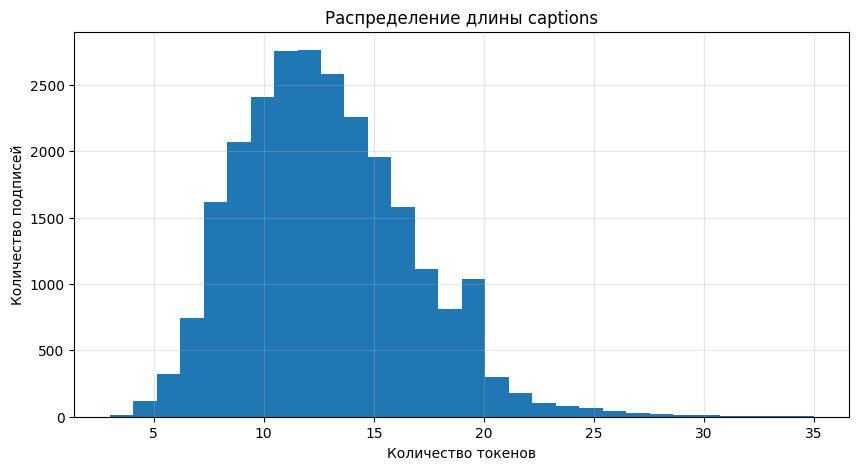

MAX_LEN: 35
Decoder input: (25000, 34)
Decoder target: (25000, 34)
Decoder input: (2500, 34)
Decoder target: (2500, 34)
Исходная подпись:
startseq a female lionist jumping in a green field with a green mountain in the background endseq

Decoder input:
[   3    2  489 4150   46    5    2   63   53   11    2   63  109    5
    6  104    4    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]

Decoder target:
[   2  489 4150   46    5    2   63   53   11    2   63  109    5    6
  104    4    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
INPUT:
startseq a female lionist jumping in a green field with a green mountain in the background endseq

TARGET:
a female lionist jumping in a green field with a green mountain in the background endseq


In [2]:
# 14. Импорты для подготовки текста

import re
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 15. Очистка подписей

def clean_caption(text):

    text = str(
        text
    ).lower()

    text = re.sub(
        r"[^a-z\s]",
        " ",
        text,
    )

    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    return (
        f"startseq "
        f"{text} "
        f"endseq"
    )


# 16. Очистка всех подписей

clean_captions_by_image = {}

for image_name, captions_list in (
    captions_by_image.items()
):

    clean_captions_by_image[
        image_name
    ] = [
        clean_caption(
            caption
        )
        for caption in captions_list
    ]


# 17. Проверка очистки

example_image = next(
    iter(
        clean_captions_by_image
    )
)

print(
    "Изображение:",
    example_image
)

print()

for caption in clean_captions_by_image[
    example_image
]:

    print(
        caption
    )



# 18. Перемешивание изображений

all_image_names = np.array(
    list(
        clean_captions_by_image.keys()
    )
)

rng = np.random.default_rng(
    SEED
)

rng.shuffle(
    all_image_names
)

print(
    "Всего изображений:",
    len(all_image_names)
)



# 19. Разделение выборки

train_names = all_image_names[
    :TRAIN_IMAGES
]

val_names = all_image_names[
    TRAIN_IMAGES:
    TRAIN_IMAGES + VAL_IMAGES
]

test_names = all_image_names[
    TRAIN_IMAGES + VAL_IMAGES:
    TRAIN_IMAGES + VAL_IMAGES + TEST_IMAGES
]

print(
    "Train:",
    len(train_names)
)

print(
    "Validation:",
    len(val_names)
)

print(
    "Test:",
    len(test_names)
)


# 20. Проверка выборок

train_set = set(
    train_names
)

val_set = set(
    val_names
)

test_set = set(
    test_names
)

print(
    "Train / Validation:",
    len(
        train_set
        & val_set
    )
)

print(
    "Train / Test:",
    len(
        train_set
        & test_set
    )
)

print(
    "Validation / Test:",
    len(
        val_set
        & test_set
    )
)


# 21. Получение подписей

def get_captions(
    image_names,
):

    result = []

    for image_name in image_names:

        result.extend(
            clean_captions_by_image[
                image_name
            ]
        )

    return result


# 22. Текстовые выборки

train_captions = get_captions(
    train_names
)

val_captions = get_captions(
    val_names
)

test_captions = get_captions(
    test_names
)

print(
    "Train captions:",
    len(train_captions)
)

print(
    "Validation captions:",
    len(val_captions)
)

print(
    "Test captions:",
    len(test_captions)
)


# 23. Токенизация

tokenizer = Tokenizer(
    oov_token="<unk>"
)

tokenizer.fit_on_texts(
    train_captions
)

VOCAB_SIZE = (
    len(
        tokenizer.word_index
    )
    + 1
)

print(
    "Размер словаря:",
    VOCAB_SIZE
)


# 24. Проверка словаря

for word, index in list(
    tokenizer.word_index.items()
)[:20]:

    print(
        index,
        word,
    )


# 25. Служебные токены

START_TOKEN = tokenizer.word_index[
    "startseq"
]

END_TOKEN = tokenizer.word_index[
    "endseq"
]

OOV_TOKEN = tokenizer.word_index[
    "<unk>"
]

print(
    "START:",
    START_TOKEN
)

print(
    "END:",
    END_TOKEN
)

print(
    "OOV:",
    OOV_TOKEN
)


# 26. Последовательности train

train_sequences = (
    tokenizer.texts_to_sequences(
        train_captions
    )
)

caption_lengths = np.array(
    [
        len(sequence)
        for sequence
        in train_sequences
    ]
)

print(
    "Минимальная длина:",
    caption_lengths.min()
)

print(
    "Средняя длина:",
    f"{caption_lengths.mean():.2f}"
)

print(
    "Максимальная длина:",
    caption_lengths.max()
)


# 27. Распределение длины подписей

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    caption_lengths,
    bins=30,
)

plt.xlabel(
    "Количество токенов"
)

plt.ylabel(
    "Количество подписей"
)

plt.title(
    "Распределение длины captions"
)

plt.grid(
    alpha=0.3
)

plt.show()



# 28. Максимальная длина

MAX_LEN = int(
    caption_lengths.max()
)

print(
    "MAX_LEN:",
    MAX_LEN
)


# 29. Подготовка последовательностей

def prepare_sequences(
    captions,
):

    sequences = (
        tokenizer.texts_to_sequences(
            captions
        )
    )

    padded = pad_sequences(
        sequences,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post",
    )

    decoder_inputs = (
        padded[
            :,
            :-1
        ]
    )

    decoder_targets = (
        padded[
            :,
            1:
        ]
    )

    return (
        decoder_inputs,
        decoder_targets,
    )



# 30. Train sequences

(
    train_decoder_inputs,
    train_decoder_targets,
) = prepare_sequences(
    train_captions
)

print(
    "Decoder input:",
    train_decoder_inputs.shape
)

print(
    "Decoder target:",
    train_decoder_targets.shape
)


# 31. Validation sequences

(
    val_decoder_inputs,
    val_decoder_targets,
) = prepare_sequences(
    val_captions
)

print(
    "Decoder input:",
    val_decoder_inputs.shape
)

print(
    "Decoder target:",
    val_decoder_targets.shape
)



# 32. Проверка последовательностей

index = 0

print(
    "Исходная подпись:"
)

print(
    train_captions[
        index
    ]
)

print()

print(
    "Decoder input:"
)

print(
    train_decoder_inputs[
        index
    ]
)

print()

print(
    "Decoder target:"
)

print(
    train_decoder_targets[
        index
    ]
)



# 33. Декодирование последовательности

input_words = [
    tokenizer.index_word.get(
        int(token),
        ""
    )
    for token in train_decoder_inputs[
        0
    ]
    if token != 0
]

target_words = [
    tokenizer.index_word.get(
        int(token),
        ""
    )
    for token in train_decoder_targets[
        0
    ]
    if token != 0
]

print(
    "INPUT:"
)

print(
    " ".join(
        input_words
    )
)

print()

print(
    "TARGET:"
)

print(
    " ".join(
        target_words
    )
)




Изображений: 6000
Уникальных: 6000
/root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images/3241892328_4ebf8b21ce.jpg
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Выход: (None, 2048)
Форма: (299, 299, 3)
Минимум: -1.0
Максимум: 0.9630775451660156
Количество батчей: 188
Форма батча: (32, 299, 299, 3)
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 163ms/step
Форма признаков: (6000, 2048)
Изображений: 6000
Размер признаков: (2048,)
Изображение: 3241892328_4ebf8b21ce.jpg
Форма: (2048,)

Первые 10 значений:
[0.08747107 0.10384691 0.0328523  0.17025724 0.504542   0.19611883
 0.18792233 0.28571653 0.01536676 0.21942112]
Признаки сохранены.
Файл существует: True
Размер: 42.37 MB


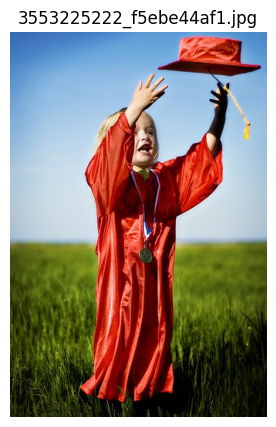

Размер вектора Inception: (2048,)

Реальные подписи:
- startseq a child in a graduation gown throws the cap in the air endseq
- startseq a child who is celebrating their graduation in a field endseq
- startseq a young child dressed in a graduation gown is throwing a graduation cap in the air endseq
- startseq a young girl throws her graduation cap into the air endseq
- startseq young girl in red graduation suit flings her hat upward into the field endseq


In [3]:
# 34. Импорты InceptionV3

import tensorflow as tf

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input


# 35. Список изображений

selected_image_names = np.concatenate(
    [
        train_names,
        val_names,
        test_names,
    ]
)

print(
    "Изображений:",
    len(selected_image_names)
)

print(
    "Уникальных:",
    len(
        np.unique(
            selected_image_names
        )
    )
)


# 36. Пути к изображениям

selected_image_paths = [
    str(
        IMAGES_DIR
        / image_name
    )
    for image_name
    in selected_image_names
]

print(
    selected_image_paths[0]
)


# 37. Экстрактор признаков

feature_extractor = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg",
)

feature_extractor.trainable = False

print(
    "Выход:",
    feature_extractor.output_shape
)


# 38. Подготовка изображения

def load_inception_image(
    image_path,
):

    image_data = tf.io.read_file(
        image_path
    )

    image_data = tf.image.decode_jpeg(
        image_data,
        channels=3,
    )

    image_data = tf.image.resize(
        image_data,
        (
            299,
            299,
        ),
    )

    image_data = tf.cast(
        image_data,
        tf.float32,
    )

    image_data = preprocess_input(
        image_data
    )

    return image_data



  # 39. Проверка подготовки

test_inception_image = (
    load_inception_image(
        selected_image_paths[0]
    )
)

print(
    "Форма:",
    test_inception_image.shape
)

print(
    "Минимум:",
    float(
        tf.reduce_min(
            test_inception_image
        )
    )
)

print(
    "Максимум:",
    float(
        tf.reduce_max(
            test_inception_image
        )
    )
)



# 40. Dataset для InceptionV3

FEATURE_BATCH_SIZE = 32

image_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        selected_image_paths
    )
    .map(
        load_inception_image,
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    .batch(
        FEATURE_BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

print(
    "Количество батчей:",
    len(image_dataset)
)



# 41. Проверка батча

for image_batch in image_dataset.take(1):

    print(
        "Форма батча:",
        image_batch.shape
    )


# 42. Извлечение признаков

image_features_array = (
    feature_extractor.predict(
        image_dataset,
        verbose=1,
    )
)

print(
    "Форма признаков:",
    image_features_array.shape
)



# 43. Словарь признаков

image_features = {
    image_name: feature
    for image_name, feature
    in zip(
        selected_image_names,
        image_features_array,
    )
}

print(
    "Изображений:",
    len(image_features)
)

print(
    "Размер признаков:",
    image_features[
        selected_image_names[0]
    ].shape
)


# 44. Проверка признаков

example_name = (
    selected_image_names[0]
)

example_features = (
    image_features[
        example_name
    ]
)

print(
    "Изображение:",
    example_name
)

print(
    "Форма:",
    example_features.shape
)

print()

print(
    "Первые 10 значений:"
)

print(
    example_features[:10]
)


# 45. Сохранение признаков

np.savez_compressed(
    "/content/flickr8k_features.npz",
    image_names=selected_image_names,
    features=image_features_array,
)

print(
    "Признаки сохранены."
)


# 46. Проверка файла признаков

features_file = Path(
    "/content/flickr8k_features.npz"
)

print(
    "Файл существует:",
    features_file.exists()
)

print(
    "Размер:",
    f"{features_file.stat().st_size / 1024 / 1024:.2f} MB"
)


# 47. Проверка результата

sample_name = random.choice(
    list(
        test_names
    )
)

sample_path = (
    IMAGES_DIR
    / sample_name
)

sample_image = Image.open(
    sample_path
).convert(
    "RGB"
)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    sample_image
)

plt.axis(
    "off"
)

plt.title(
    sample_name
)

plt.show()

print(
    "Размер вектора Inception:",
    image_features[
        sample_name
    ].shape
)

print()

print(
    "Реальные подписи:"
)

for caption in clean_captions_by_image[
    sample_name
]:

    print(
        "-",
        caption
    )





Train: (25000,)
Validation: (2500,)
Train captions: (25000, 34)
Validation captions: (2500, 34)
Размеры выборок корректны.
(6000, 2048)
Train batches: 391
Validation batches: 40


Model: "Image_Caption_Seq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_tokens      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 34, 256)   │  1,747,456 │ decoder_tokens[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_to_h (Dense)  │ (None, 256)       │    524,544 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_to_c (Dense)  │ (None, 256)       │    524,544 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 34, 256), │    525,312 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ image_to_h[0][0], │
│                     │ (None, 256)]      │            │ image_to_c[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_classifier    │ (None, 34, 6826)  │  1,754,282 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,076,138 (19.36 MB)

 Trainable params: 5,076,138 (19.36 MB)

 Non-trainable params: 0 (0.00 B)

Image features: (64, 2048)
Decoder input: (64, 34)
Target: (64, 34)
Prediction: (64, 34, 6826)
Epoch 1/15
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 5.4751 - masked_accuracy: 0.1883
Epoch 1: val_loss improved from None to 4.16582, saving model to /content/best_caption_model.weights.h5

Epoch 1: finished saving model to /content/best_caption_model.weights.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 4.7583 - masked_accuracy: 0.2352 - val_loss: 4.1658 - val_masked_accuracy: 0.2917 - learning_rate: 0.0010
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.9259 - masked_accuracy: 0.3052
Epoch 2: val_loss improved from 4.16582 to 3.85880, saving model to /content/best_caption_model.weights.h5

Epoch 2: finished saving model to /content/best_caption_model.weights.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 3.8551 - masked_accuracy: 0.3120 - val_loss: 3.8588 - val_masked_accuracy: 0.3177 - learning_rate: 0.0010
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 3

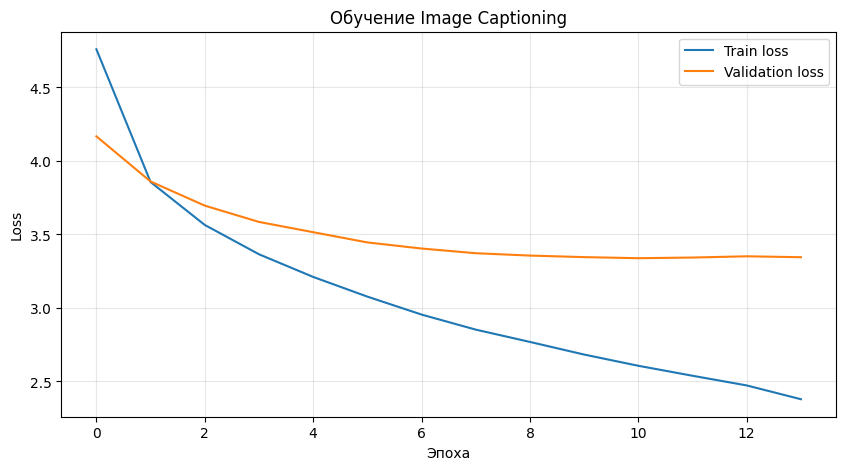

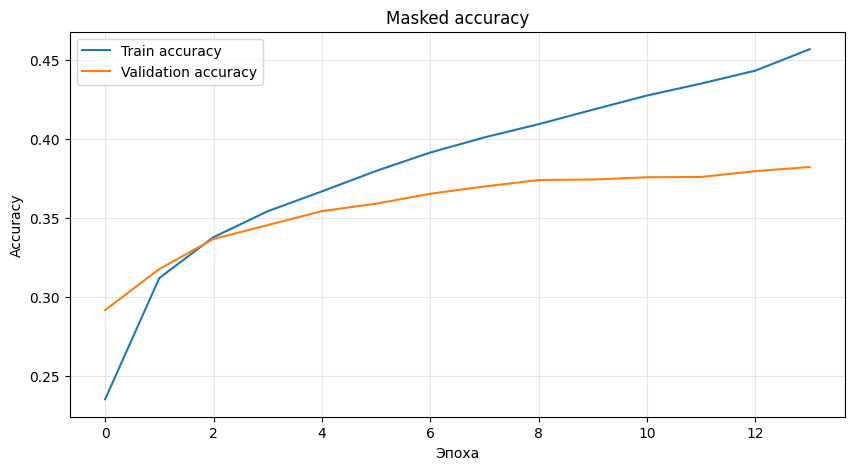

In [5]:
# 48. Индексы признаков

feature_index_by_name = {
    str(image_name): index
    for index, image_name
    in enumerate(
        selected_image_names
    )
}


def create_feature_indices(
    image_names,
):

    indices = []

    for image_name in image_names:

        captions_count = len(
            clean_captions_by_image[
                image_name
            ]
        )

        image_index = (
            feature_index_by_name[
                str(image_name)
            ]
        )

        indices.extend(
            [image_index]
            * captions_count
        )

    return np.array(
        indices,
        dtype=np.int32,
    )




# 49. Индексы выборок

train_feature_indices = (
    create_feature_indices(
        train_names
    )
)

val_feature_indices = (
    create_feature_indices(
        val_names
    )
)

print(
    "Train:",
    train_feature_indices.shape
)

print(
    "Validation:",
    val_feature_indices.shape
)

print(
    "Train captions:",
    train_decoder_inputs.shape
)

print(
    "Validation captions:",
    val_decoder_inputs.shape
)


# 50. Проверка индексов

assert (
    len(train_feature_indices)
    == len(train_decoder_inputs)
)

assert (
    len(val_feature_indices)
    == len(val_decoder_inputs)
)

print(
    "Размеры выборок корректны."
)


# 51. Tensor признаков

features_tensor = tf.constant(
    image_features_array,
    dtype=tf.float32,
)

print(
    features_tensor.shape
)


# 52. Dataset для обучения

def create_caption_dataset(
    feature_indices,
    decoder_inputs,
    decoder_targets,
    training=False,
):

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                feature_indices,
                decoder_inputs,
                decoder_targets,
            )
        )
    )

    if training:

        dataset = dataset.shuffle(
            len(feature_indices),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    def attach_features(
        feature_index,
        decoder_input,
        decoder_target,
    ):

        image_feature = tf.gather(
            features_tensor,
            feature_index,
        )

        inputs = {
            "image_features":
                image_feature,

            "decoder_tokens":
                decoder_input,
        }

        return (
            inputs,
            decoder_target,
        )

    dataset = dataset.map(
        attach_features,
        num_parallel_calls=
            tf.data.AUTOTUNE,
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset



# 53. Train и validation datasets

train_dataset = (
    create_caption_dataset(
        train_feature_indices,
        train_decoder_inputs,
        train_decoder_targets,
        training=True,
    )
)

val_dataset = (
    create_caption_dataset(
        val_feature_indices,
        val_decoder_inputs,
        val_decoder_targets,
        training=False,
    )
)

print(
    "Train batches:",
    len(train_dataset)
)

print(
    "Validation batches:",
    len(val_dataset)
)


# 54. Входы модели

image_input = tf.keras.layers.Input(
    shape=(2048,),
    name="image_features",
)

decoder_input = tf.keras.layers.Input(
    shape=(MAX_LEN - 1,),
    dtype=tf.int32,
    name="decoder_tokens",
)


# 55. Состояния изображения

image_to_h = tf.keras.layers.Dense(
    LATENT_DIM,
    activation="tanh",
    name="image_to_h",
)

image_to_c = tf.keras.layers.Dense(
    LATENT_DIM,
    activation="tanh",
    name="image_to_c",
)

initial_h = image_to_h(
    image_input
)

initial_c = image_to_c(
    image_input
)


# 56. Embedding декодера

decoder_embedding_layer = (
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=LATENT_DIM,
        mask_zero=False,
        name="decoder_embedding",
    )
)

decoder_embedding = (
    decoder_embedding_layer(
        decoder_input
    )
)



# 57. LSTM-декодер

decoder_lstm_layer = (
    tf.keras.layers.LSTM(
        LATENT_DIM,
        return_sequences=True,
        return_state=True,
        name="decoder_lstm",
    )
)

(
    decoder_outputs,
    decoder_h,
    decoder_c,
) = decoder_lstm_layer(
    decoder_embedding,
    initial_state=[
        initial_h,
        initial_c,
    ],
)



# 58. Выходной слой

decoder_dense_layer = (
    tf.keras.layers.Dense(
        VOCAB_SIZE,
        activation="softmax",
        name="token_classifier",
    )
)

token_predictions = (
    decoder_dense_layer(
        decoder_outputs
    )
)


# 59. Модель генерации описаний

caption_model = tf.keras.Model(
    inputs=[
        image_input,
        decoder_input,
    ],
    outputs=token_predictions,
    name="Image_Caption_Seq2Seq",
)

caption_model.summary()



# 60. Masked loss

loss_object = (
    tf.keras.losses
    .SparseCategoricalCrossentropy(
        reduction="none"
    )
)


def masked_loss(
    y_true,
    y_pred,
):

    loss = loss_object(
        y_true,
        y_pred,
    )

    mask = tf.not_equal(
        y_true,
        0,
    )

    mask = tf.cast(
        mask,
        loss.dtype,
    )

    loss = (
        loss
        * mask
    )

    return (
        tf.reduce_sum(loss)
        /
        tf.reduce_sum(mask)
    )



# 61. Masked accuracy

def masked_accuracy(
    y_true,
    y_pred,
):

    predicted_tokens = tf.argmax(
        y_pred,
        axis=-1,
        output_type=y_true.dtype,
    )

    matches = tf.equal(
        y_true,
        predicted_tokens,
    )

    mask = tf.not_equal(
        y_true,
        0,
    )

    matches = tf.logical_and(
        matches,
        mask,
    )

    matches = tf.cast(
        matches,
        tf.float32,
    )

    mask = tf.cast(
        mask,
        tf.float32,
    )

    return (
        tf.reduce_sum(matches)
        /
        tf.reduce_sum(mask)
    )


# 62. Компиляция

optimizer = (
    tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

caption_model.compile(
    optimizer=optimizer,
    loss=masked_loss,
    metrics=[
        masked_accuracy
    ],
)


# 63. Проверка модели

for (
    batch_inputs,
    batch_targets,
) in train_dataset.take(1):

    batch_predictions = (
        caption_model(
            batch_inputs,
            training=False,
        )
    )

    print(
        "Image features:",
        batch_inputs[
            "image_features"
        ].shape
    )

    print(
        "Decoder input:",
        batch_inputs[
            "decoder_tokens"
        ].shape
    )

    print(
        "Target:",
        batch_targets.shape
    )

    print(
        "Prediction:",
        batch_predictions.shape
    )


# 64. Callbacks

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1,
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/"
        "best_caption_model.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
]



# 65. Обучение модели

history = caption_model.fit(
    train_dataset,
    validation_data=
        val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)



# 66. График Loss

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history[
        "loss"
    ],
    label="Train loss",
)

plt.plot(
    history.history[
        "val_loss"
    ],
    label="Validation loss",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Обучение Image Captioning"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()



# 67. График Accuracy

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history.history[
        "masked_accuracy"
    ],
    label="Train accuracy",
)

plt.plot(
    history.history[
        "val_masked_accuracy"
    ],
    label="Validation accuracy",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Masked accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()






Слов в словаре: 6825
Изображение: 509123893_07b8ea82a9.jpg

Предсказание:
a girl in a pink dress is standing in front of a tree


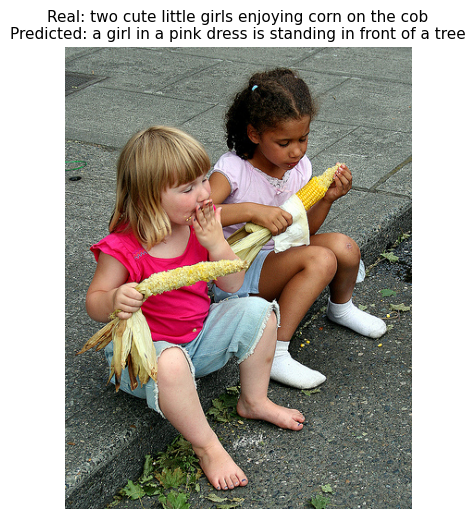

['3537520829_aab733e16c.jpg' '2757803246_8aa3499d26.jpg'
 '391020801_aaaae1e42b.jpg' '1802092493_7b44fdb6b9.jpg'
 '2460126267_0deea8b645.jpg' '3631671718_d712821757.jpg'
 '2862004252_53894bb28b.jpg' '2969380952_9f1eb7f93b.jpg'
 '1251558317_4ef844b775.jpg' '811663364_4b350a62ce.jpg']


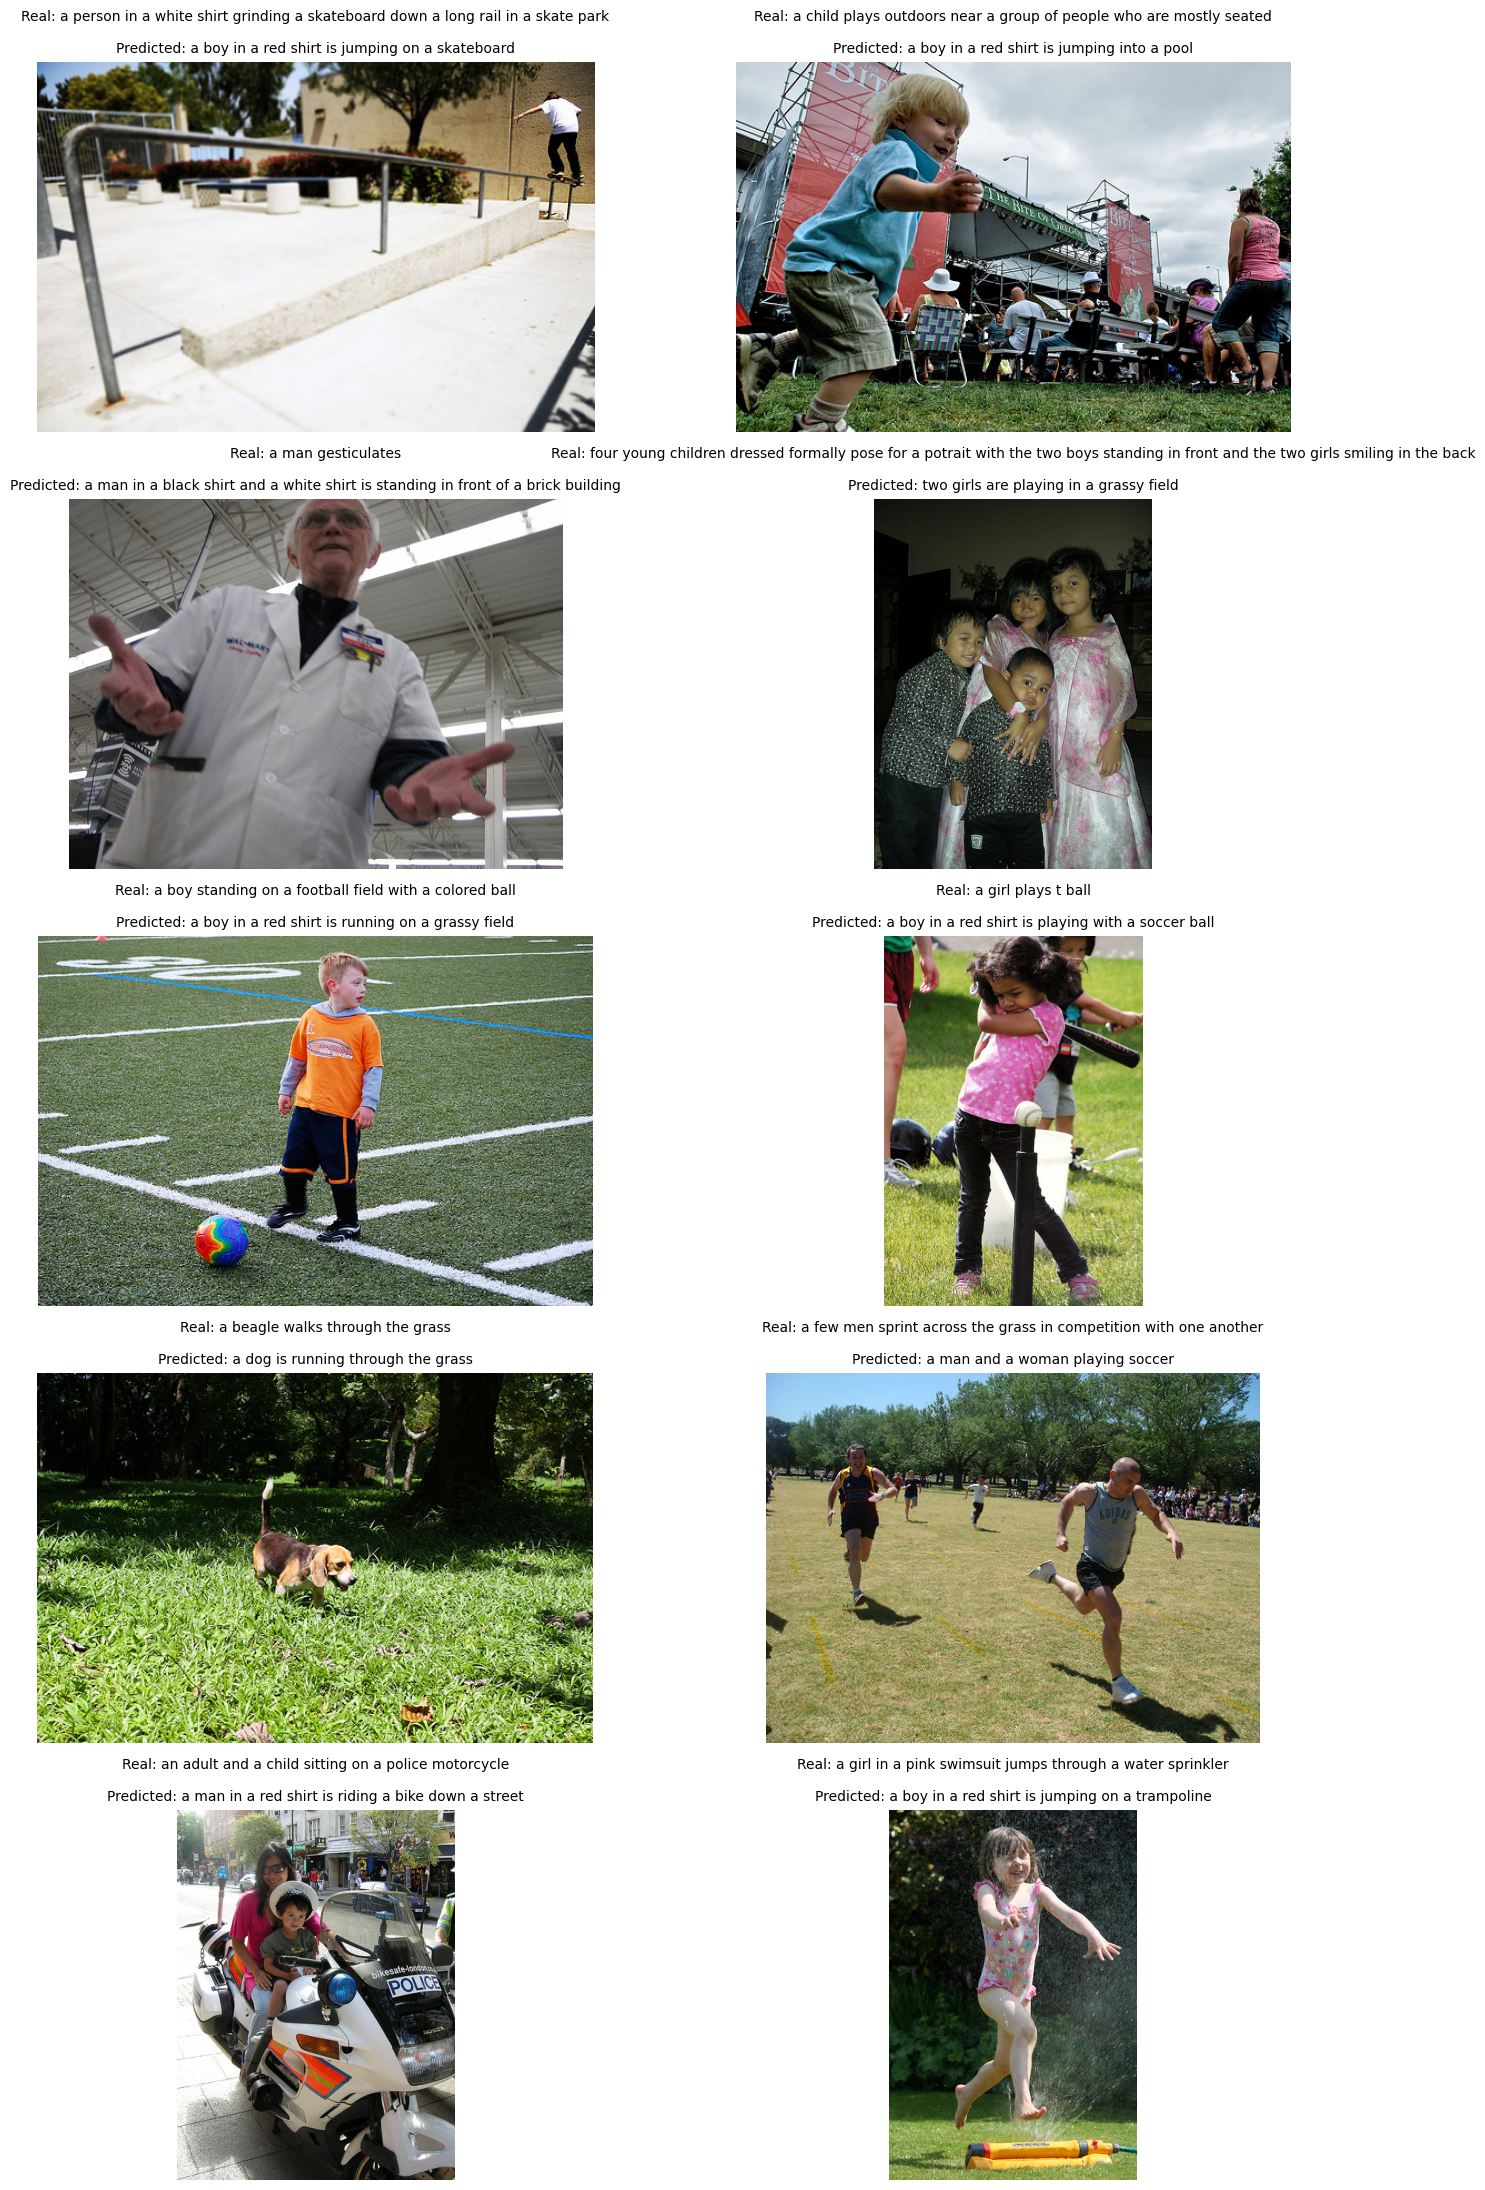

Пример 1
Файл: 3537520829_aab733e16c.jpg

Реальные описания:
- a person in a white shirt grinding a skateboard down a long rail in a skate park
- a person in a white shirt skateboarding off a rail
- a skateboarder grinds down a long rail
- a skateboarder rides down a rail
- a skateboarder riding a rail

Описание модели:
a boy in a red shirt is jumping on a skateboard

Пример 2
Файл: 2757803246_8aa3499d26.jpg

Реальные описания:
- a child plays outdoors near a group of people who are mostly seated
- a little blond boy is running around in the grass behind a row of benches
- a little boy is running towards a group of people
- a little boy runs around while others look at a stage
- a small child wearing blue smiles as he stands behind a group of people

Описание модели:
a boy in a red shirt is jumping into a pool

Пример 3
Файл: 391020801_aaaae1e42b.jpg

Реальные описания:
- a man gesticulates
- a man in a white shirt holding both hands out
- an elderly male wearing a white wal mart smock

In [6]:
# 68. Обратный словарь

index_to_word = {
    index: word
    for word, index
    in tokenizer.word_index.items()
}

print(
    "Слов в словаре:",
    len(index_to_word)
)


# 69. Генерация описания

def generate_caption(
    image_name,
):

    image_feature = (
        image_features[
            image_name
        ]
    )

    image_feature = np.expand_dims(
        image_feature,
        axis=0,
    )

    decoder_sequence = np.zeros(
        (
            1,
            MAX_LEN - 1,
        ),
        dtype=np.int32,
    )

    decoder_sequence[
        0,
        0
    ] = START_TOKEN

    generated_words = []

    for step in range(
        MAX_LEN - 2
    ):

        predictions = caption_model.predict(
            {
                "image_features":
                    image_feature,

                "decoder_tokens":
                    decoder_sequence,
            },
            verbose=0,
        )

        token_probabilities = (
            predictions[
                0,
                step,
                :
            ].copy()
        )

        # Не разрешаем генерировать padding
        token_probabilities[
            0
        ] = 0.0

        # START нужен только на первом входе
        token_probabilities[
            START_TOKEN
        ] = 0.0

        predicted_token = int(
            np.argmax(
                token_probabilities
            )
        )

        if (
            predicted_token
            == END_TOKEN
        ):
            break

        predicted_word = (
            index_to_word.get(
                predicted_token
            )
        )

        if predicted_word is None:
            break

        generated_words.append(
            predicted_word
        )

        next_position = (
            step + 1
        )

        if (
            next_position
            >= MAX_LEN - 1
        ):
            break

        decoder_sequence[
            0,
            next_position
        ] = predicted_token

    return " ".join(
        generated_words
    )



# 70. Проверка генерации

test_image_name = (
    test_names[0]
)

predicted_caption = (
    generate_caption(
        test_image_name
    )
)

print(
    "Изображение:",
    test_image_name
)

print()

print(
    "Предсказание:"
)

print(
    predicted_caption
)


# 71. Очистка подписи

def remove_special_tokens(
    caption,
):

    caption = caption.replace(
        "startseq",
        "",
    )

    caption = caption.replace(
        "endseq",
        "",
    )

    return caption.strip()



# 72. Один тестовый пример

image_path = (
    IMAGES_DIR
    / test_image_name
)

image = Image.open(
    image_path
).convert(
    "RGB"
)

real_caption = remove_special_tokens(
    clean_captions_by_image[
        test_image_name
    ][0]
)

predicted_caption = (
    generate_caption(
        test_image_name
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.imshow(
    image
)

plt.axis(
    "off"
)

plt.title(
    f"Real: {real_caption}\n"
    f"Predicted: {predicted_caption}",
    fontsize=11,
)

plt.show()



# 73. Тестовые изображения

demo_rng = np.random.default_rng(
    SEED
)

demo_names = demo_rng.choice(
    test_names,
    size=10,
    replace=False,
)

print(
    demo_names
)


# 74. Генерация 10 описаний

demo_results = []

for image_name in demo_names:

    real_caption = (
        remove_special_tokens(
            clean_captions_by_image[
                image_name
            ][0]
        )
    )

    predicted_caption = (
        generate_caption(
            image_name
        )
    )

    demo_results.append(
        {
            "image":
                image_name,

            "real":
                real_caption,

            "predicted":
                predicted_caption,
        }
    )



# 75. Демонстрация работы модели

plt.figure(
    figsize=(15, 22)
)

for index, result in enumerate(
    demo_results
):

    image_path = (
        IMAGES_DIR
        / result[
            "image"
        ]
    )

    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    plt.subplot(
        5,
        2,
        index + 1,
    )

    plt.imshow(
        image
    )

    plt.title(
        f"Real: "
        f"{result['real']}\n\n"
        f"Predicted: "
        f"{result['predicted']}",
        fontsize=10,
    )

    plt.axis(
        "off"
    )

plt.tight_layout()
plt.show()



# 76. Таблица результатов

results_df = pd.DataFrame(
    [
        {
            "Image":
                result[
                    "image"
                ],

            "Real caption":
                result[
                    "real"
                ],

            "Predicted caption":
                result[
                    "predicted"
                ],
        }
        for result
        in demo_results
    ]
)

results_df




# 77. Подробные результаты

for number, image_name in enumerate(
    demo_names,
    start=1,
):

    print(
        "=" * 80
    )

    print(
        f"Пример {number}"
    )

    print(
        "Файл:",
        image_name
    )

    print()

    print(
        "Реальные описания:"
    )

    for caption in (
        clean_captions_by_image[
            image_name
        ]
    ):

        print(
            "-",
            remove_special_tokens(
                caption
            )
        )

    print()

    print(
        "Описание модели:"
    )

    print(
        generate_caption(
            image_name
        )
    )

    print()



# 78. Сохранение модели

caption_model.save(
    "/content/"
    "flickr8k_caption_model.keras"
)

print(
    "Модель сохранена."
)





['two', 'cute', 'little', 'girls', 'enjoying', 'corn', 'on', 'the', 'cob']
['two', 'girls', 'enjoy', 'corn', 'on', 'the', 'cob', 'while', 'sitting', 'on', 'a', 'curb']
['two', 'little', 'girls', 'sitting', 'on', 'the', 'edge', 'of', 'a', 'street', 'eating', 'corn', 'on', 'the', 'cob']
['two', 'young', 'girls', 'are', 'sitting', 'on', 'the', 'street', 'eating', 'corn']
['two', 'young', 'girls', 'eating', 'corn', 'on', 'the', 'cob', 'on', 'a', 'sidewalk', 'without', 'shoes']
Изображение: 509123893_07b8ea82a9.jpg
Prediction: a girl in a pink dress is standing in front of a tree

BLEU-1: 0.1538
BLEU-2: 0.1132
BLEU-4: 0.0329
Обработано: 10/100
Обработано: 20/100
Обработано: 30/100
Обработано: 40/100
Обработано: 50/100
Обработано: 60/100
Обработано: 70/100
Обработано: 80/100
Обработано: 90/100
Обработано: 100/100
Средний BLEU-1: 0.4976
Средний BLEU-2: 0.3103
Средний BLEU-4: 0.1073


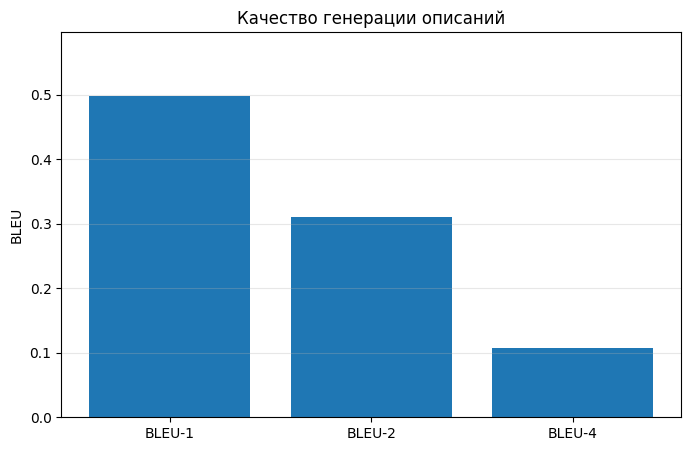

Результаты сохранены.
Результаты эксперимента
----------------------------------------
Лучший val_loss: 3.3371
Лучший val_accuracy: 0.3824
BLEU-1: 0.4976
BLEU-2: 0.3103
BLEU-4: 0.1073


In [8]:
# 81. Установка NLTK

%pip install -q nltk


# 82. Импорты для BLEU

from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction,
)



# 83. Подготовка эталонных подписей

def get_reference_captions(
    image_name,
):

    references = []

    for caption in (
        clean_captions_by_image[
            image_name
        ]
    ):

        clean_text = (
            remove_special_tokens(
                caption
            )
        )

        references.append(
            clean_text.split()
        )

    return references



# 84. Проверка эталонов

example_name = test_names[0]

references = (
    get_reference_captions(
        example_name
    )
)

for reference in references:

    print(
        reference
    )




# 85. Функция BLEU

smoothing = (
    SmoothingFunction()
)


def calculate_bleu(
    image_name,
):

    references = (
        get_reference_captions(
            image_name
        )
    )

    prediction = (
        generate_caption(
            image_name
        )
    )

    hypothesis = (
        prediction.split()
    )

    if not hypothesis:

        return (
            0.0,
            0.0,
            0.0,
        )

    bleu_1 = sentence_bleu(
        references,
        hypothesis,
        weights=(
            1.0,
            0.0,
            0.0,
            0.0,
        ),
        smoothing_function=
            smoothing.method1,
    )

    bleu_2 = sentence_bleu(
        references,
        hypothesis,
        weights=(
            0.5,
            0.5,
            0.0,
            0.0,
        ),
        smoothing_function=
            smoothing.method1,
    )

    bleu_4 = sentence_bleu(
        references,
        hypothesis,
        weights=(
            0.25,
            0.25,
            0.25,
            0.25,
        ),
        smoothing_function=
            smoothing.method1,
    )

    return (
        bleu_1,
        bleu_2,
        bleu_4,
    )



# 86. BLEU одного изображения

example_bleu = (
    calculate_bleu(
        example_name
    )
)

print(
    "Изображение:",
    example_name
)

print(
    "Prediction:",
    generate_caption(
        example_name
    )
)

print()

print(
    "BLEU-1:",
    f"{example_bleu[0]:.4f}"
)

print(
    "BLEU-2:",
    f"{example_bleu[1]:.4f}"
)

print(
    "BLEU-4:",
    f"{example_bleu[2]:.4f}"
)




# 87. Выбор изображений для BLEU

BLEU_TEST_SIZE = 100

bleu_rng = np.random.default_rng(
    SEED
)

bleu_test_names = bleu_rng.choice(
    test_names,
    size=BLEU_TEST_SIZE,
    replace=False,
)



# 88. Расчёт BLEU на test

bleu_results = []

for index, image_name in enumerate(
    bleu_test_names,
    start=1,
):

    bleu_1, bleu_2, bleu_4 = (
        calculate_bleu(
            image_name
        )
    )

    bleu_results.append(
        {
            "image":
                image_name,

            "bleu_1":
                bleu_1,

            "bleu_2":
                bleu_2,

            "bleu_4":
                bleu_4,
        }
    )

    if (
        index % 10
        == 0
    ):

        print(
            f"Обработано: "
            f"{index}/"
            f"{BLEU_TEST_SIZE}"
        )



  # 89. Средние значения BLEU

bleu_df = pd.DataFrame(
    bleu_results
)

mean_bleu_1 = (
    bleu_df[
        "bleu_1"
    ].mean()
)

mean_bleu_2 = (
    bleu_df[
        "bleu_2"
    ].mean()
)

mean_bleu_4 = (
    bleu_df[
        "bleu_4"
    ].mean()
)

print(
    "Средний BLEU-1:",
    f"{mean_bleu_1:.4f}"
)

print(
    "Средний BLEU-2:",
    f"{mean_bleu_2:.4f}"
)

print(
    "Средний BLEU-4:",
    f"{mean_bleu_4:.4f}"
)





# 90. График BLEU

bleu_names = [
    "BLEU-1",
    "BLEU-2",
    "BLEU-4",
]

bleu_values = [
    mean_bleu_1,
    mean_bleu_2,
    mean_bleu_4,
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    bleu_names,
    bleu_values,
)

plt.ylabel(
    "BLEU"
)

plt.title(
    "Качество генерации описаний"
)

plt.ylim(
    0,
    max(bleu_values) * 1.2
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.show()



# 91. Итоговая таблица

summary_df = pd.DataFrame(
    {
        "Показатель": [
            "Train images",
            "Validation images",
            "Test images",
            "Vocabulary size",
            "Maximum caption length",
            "Latent dimension",
            "Epochs",
            "Best validation loss",
            "Best validation accuracy",
            "BLEU-1",
            "BLEU-2",
            "BLEU-4",
        ],

        "Значение": [
            len(train_names),
            len(val_names),
            len(test_names),
            VOCAB_SIZE,
            MAX_LEN,
            LATENT_DIM,
            len(
                history.history[
                    "loss"
                ]
            ),
            round(
                min(
                    history.history[
                        "val_loss"
                    ]
                ),
                4,
            ),
            round(
                max(
                    history.history[
                        "val_masked_accuracy"
                    ]
                ),
                4,
            ),
            round(
                mean_bleu_1,
                4,
            ),
            round(
                mean_bleu_2,
                4,
            ),
            round(
                mean_bleu_4,
                4,
            ),
        ],
    }
)

summary_df



# 92. Сохранение результатов

results_df.to_csv(
    "/content/"
    "caption_examples.csv",
    index=False,
)

bleu_df.to_csv(
    "/content/"
    "bleu_results.csv",
    index=False,
)

summary_df.to_csv(
    "/content/"
    "experiment_summary.csv",
    index=False,
)

print(
    "Результаты сохранены."
)



# 94. Результаты для отчёта

print(
    "Результаты эксперимента"
)

print(
    "-" * 40
)

print(
    "Лучший val_loss:",
    f"{min(history.history['val_loss']):.4f}"
)

print(
    "Лучший val_accuracy:",
    f"{max(history.history['val_masked_accuracy']):.4f}"
)

print(
    "BLEU-1:",
    f"{mean_bleu_1:.4f}"
)

print(
    "BLEU-2:",
    f"{mean_bleu_2:.4f}"
)

print(
    "BLEU-4:",
    f"{mean_bleu_4:.4f}"
)








































































